Preparation

In [2]:
# Dependencies

# Standard Dependencies
import os
import numpy as np
import pandas as pd
from math import sqrt

# Visualization
from pylab import *
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from statistics import median
from scipy import signal
from math import factorial
from scipy.special import factorial
#from scipy.misc import fatorial
import scipy.stats as stats
from scipy.stats import sem, binom, lognorm, poisson, bernoulli, spearmanr
from scipy.fftpack import fft, fftshift

# Scikit-learn for Machine Learning models
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Read in csv of Toy Dataset
# We will use this dataset throughout the tutorial
df = pd.read_csv('toy_dataset.csv')

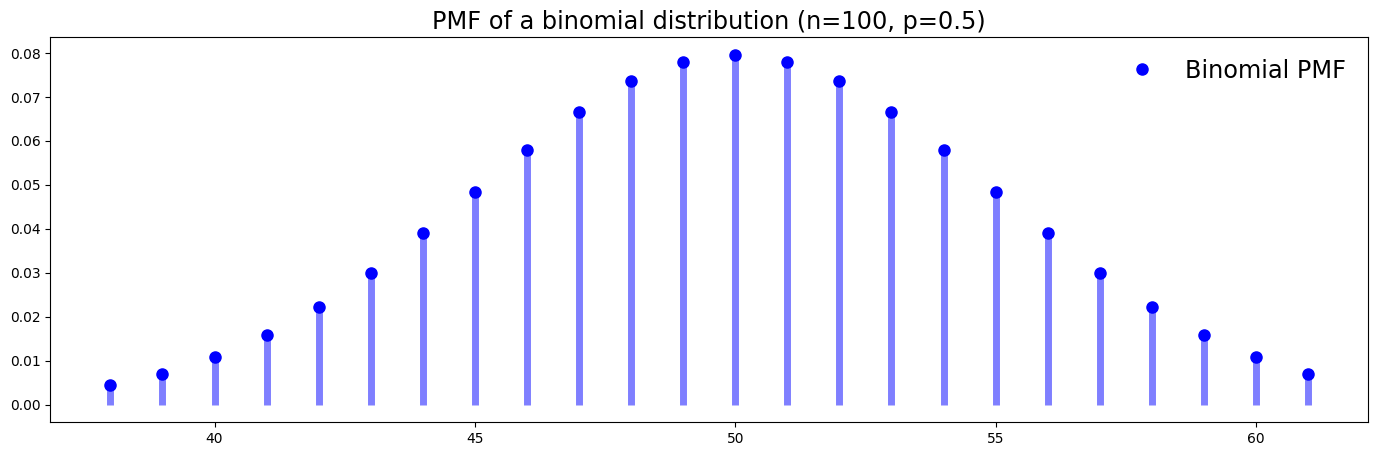

In [3]:
#PMF Visualisation
n = 100
p = 0.5

fig, ax = plt.subplots(1, 1, figsize=(17, 5))
x = np.arange(binom.ppf(0.01, n, p), binom.ppf(0.99, n, p))
ax.plot(x, binom.pmf(x, n, p), 'bo', ms=8, label='Binomial PMF')
ax.vlines(x, 0, binom.pmf(x, n, p), colors='b', lw=5, alpha=0.5)
rv = binom(n, p)
#ax.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=1, label='frozen PMF')
ax.legend(loc='best', frameon=False, fontsize='xx-large')
plt.title('PMF of a binomial distribution (n=100, p=0.5)', fontsize='xx-large')
plt.show()

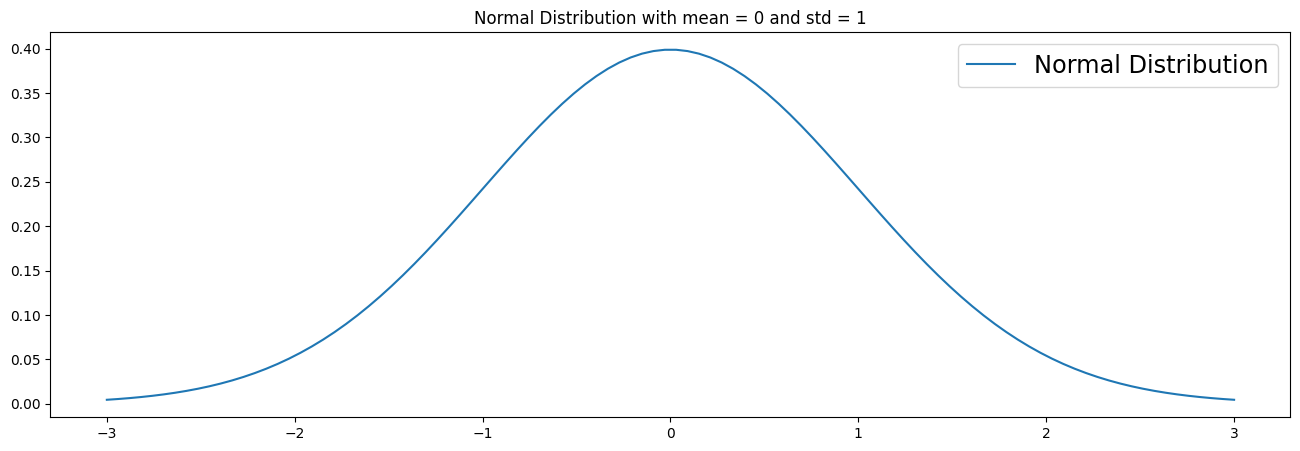

In [4]:
# Plot normal distibution
mu = 0
variance = 1
sigma = sqrt(variance)
x = np.linspace(mu - 3*sigma, mu + 3*sigma, 100)
plt.figure(figsize=(16,5))
plt.plot(x, stats.norm.pdf(x, mu, sigma), label='Normal Distribution')
plt.title('Normal Distribution with mean = 0 and std = 1')
plt.legend(fontsize='xx-large')
plt.show()

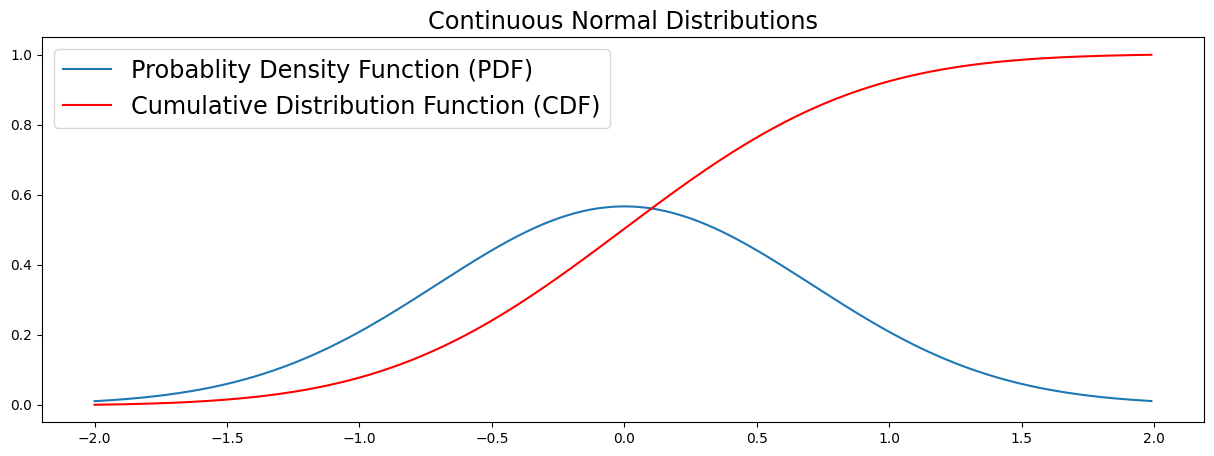

In [5]:
# Data
x = np.arange(-2, 2, 0.01)
y = exp(-x ** 2)

# Normalize data
y = y / (0.01 * y).sum()

# Plot the PDF and CDF
plt.figure(figsize=(15,5))
plt.title('Continuous Normal Distributions', fontsize='xx-large')
plot(x, y, label='Probablity Density Function (PDF)')
plot(x, np.cumsum(y*0.01), 'r', label='Cumulative Distribution Function (CDF)')
plt.legend(fontsize='xx-large')
plt.show()

In [6]:
# Uniform distribution (between 0 and 1)
uniform_dist = np.random.random(1000)
uniform_df = pd.DataFrame({'value': uniform_dist})
uniform_dist = pd.Series(uniform_dist)

Text(0.5, 1.0, 'Scatterplot of a Random/Uniform Distribution ')

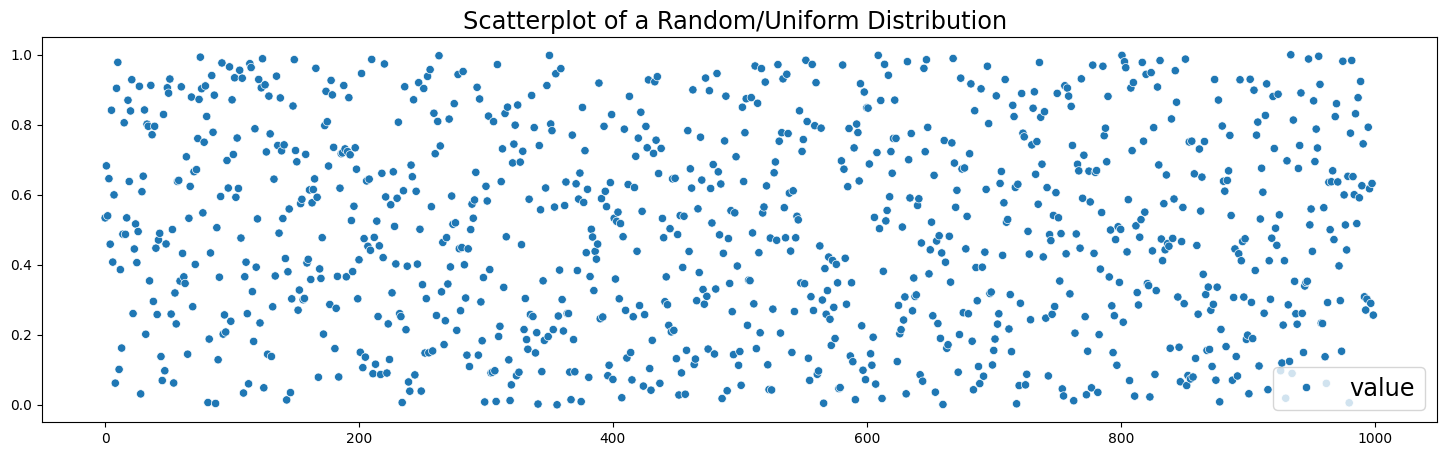

In [7]:
plt.figure(figsize=(18, 5))
sns.scatterplot(data=uniform_df)
plt.legend(fontsize='xx-large')
plt.title('Scatterplot of a Random/Uniform Distribution ', fontsize='xx-large')

C:\Users\ADITYA\AppData\Local\Temp\ipykernel_15232\603073056.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(uniform_df)


Text(0.5, 1.0, 'Random/Uniform distribution ')

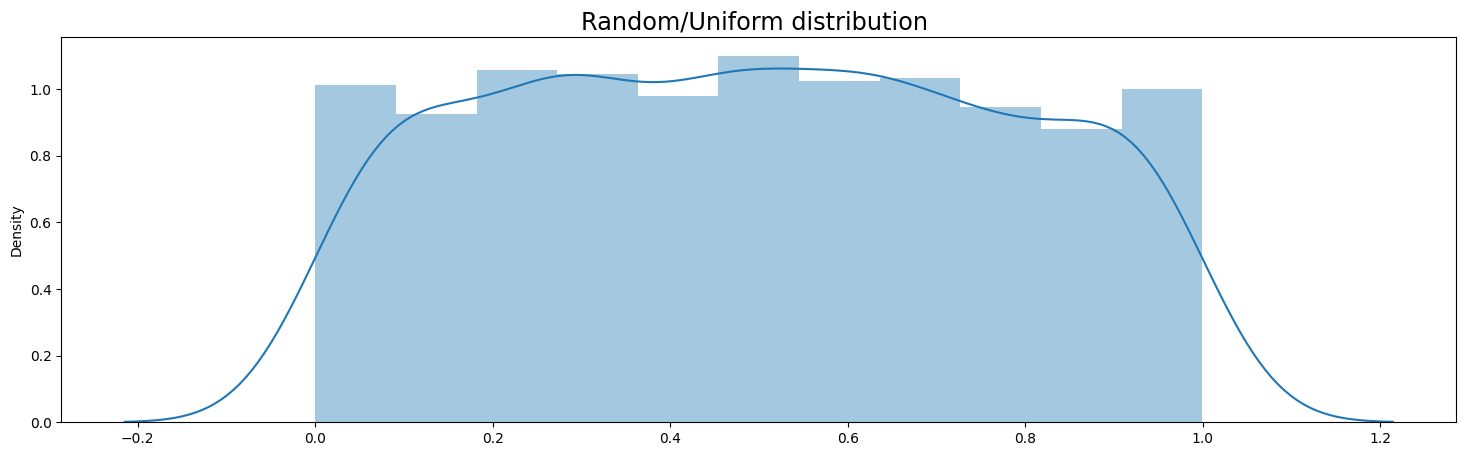

In [8]:
plt.figure(figsize=(18, 5))
sns.distplot(uniform_df)
plt.title('Random/Uniform distribution ', fontsize='xx-large')

In [9]:
# Generate Normal Distribution
normal_dist = np.random.randn(10000)
normal_df = pd.DataFrame({'value': normal_dist})
# Create a pandas Series for easy sample function
normal_dist = pd.Series(normal_dist)

normal_dist2 = np.random.randn(10000)
normal_df2 = pd.DataFrame({'value': normal_dist2})
# Create a Pandas Series for easy sample function
normal_dist2 = pd.Series(normal_dist)
normal_df_total = pd.DataFrame({'value1': normal_dist, 'value2': normal_dist2})

Text(0.5, 1.0, 'Scatterplot of a Normal Distribution')

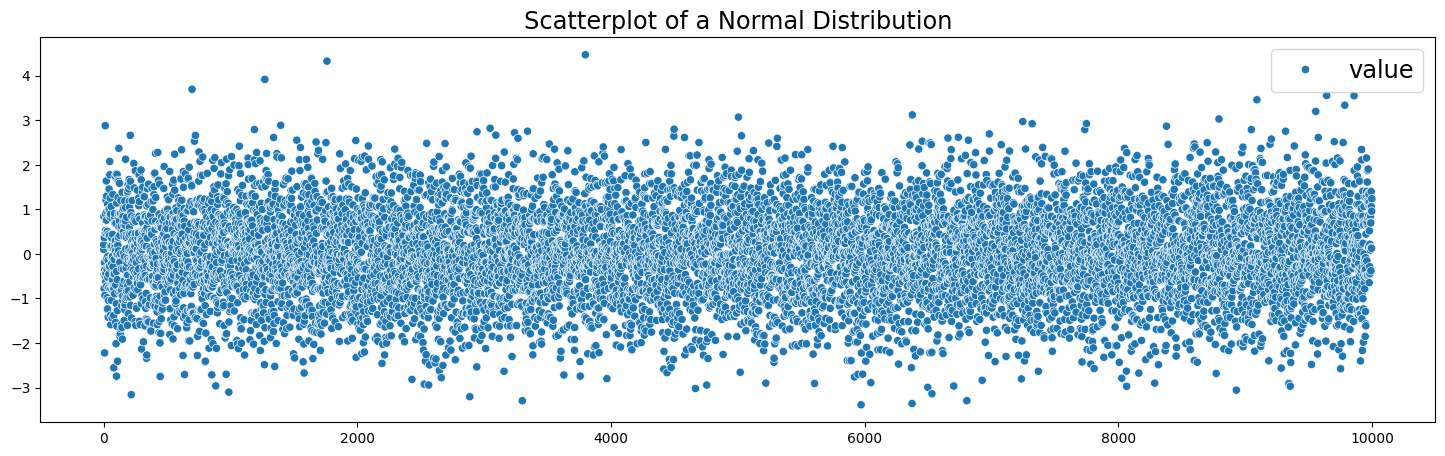

In [10]:
# Scatterplot
plt.figure(figsize=(18,5))
sns.scatterplot(data=normal_df)
plt.legend(fontsize='xx-large')
plt.title('Scatterplot of a Normal Distribution', fontsize='xx-large')   

C:\Users\ADITYA\AppData\Local\Temp\ipykernel_15232\2492441267.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(normal_df)


Text(0.5, 1.0, 'Normal distribution (n=1000)')

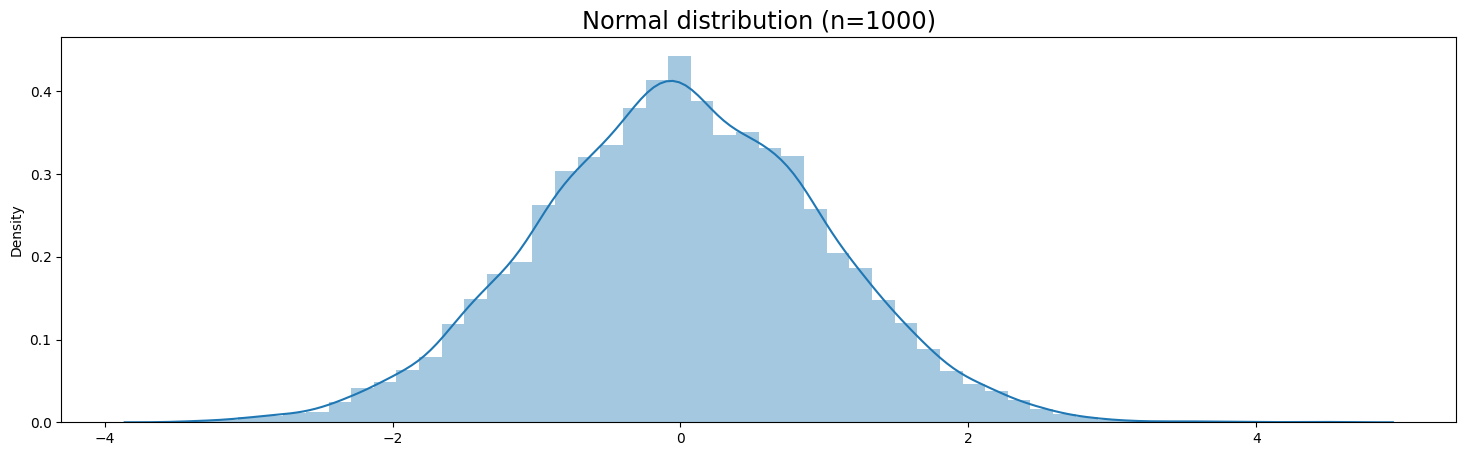

In [11]:
# Normal Distribution as a Bell Curve
plt.figure(figsize=(18,5))
sns.distplot(normal_df)
plt.title('Normal distribution (n=1000)', fontsize='xx-large')

Text(0.5, 1.0, 'Bernoulli Distribution: p = 0.6, n = 1000')

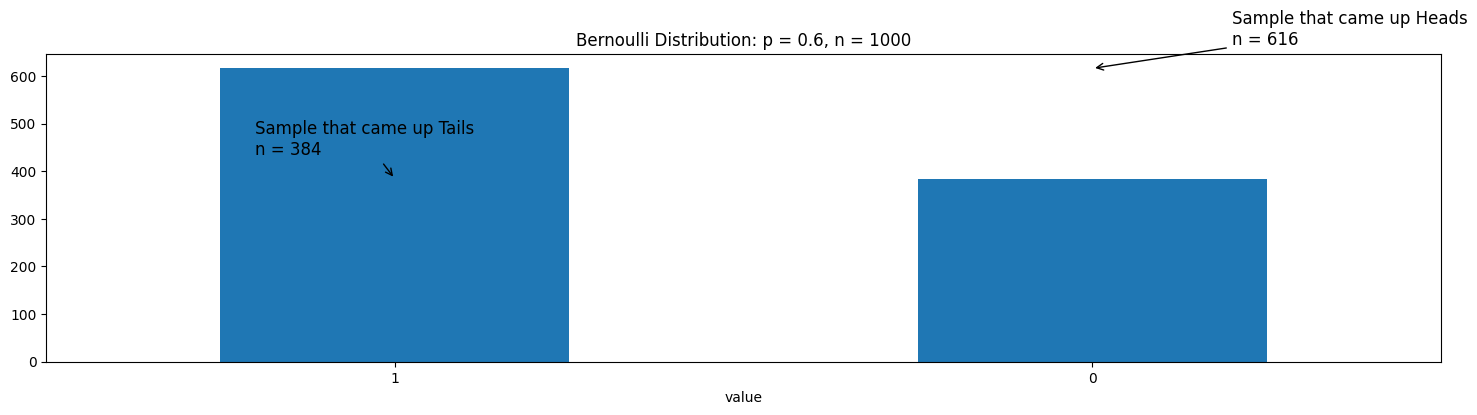

In [12]:
# Change of heads(outcome 1)
p = 0.6

# Create Bernoulli sample
bern_dist = bernoulli.rvs(p, size=1000)
bern_df = pd.DataFrame({'value': bern_dist})
bern_values = bern_df['value'].value_counts()

# Plot Distribution
plt.figure(figsize=(18, 4))
bern_values.plot(kind='bar', rot=0)
plt.annotate(
    'Sample that came up Tails\nn = {}'.format(bern_values[0]),   # TEXT FIRST
    xy=(0, bern_values[0]), 
    xytext=(0 - 0.2, bern_values[0] + 50),
    fontsize='large',
    color='black',
    arrowprops=dict(arrowstyle="->")
)


plt.annotate(
    'Sample that came up Heads\nn = {}'.format(bern_values[1]),   # remove s=
    xy=(1, bern_values[1]),
    xytext=(1 + 0.2, bern_values[1] + 50),
    fontsize='large',
    color='black',
    arrowprops=dict(arrowstyle="->")
)


plt.title('Bernoulli Distribution: p = 0.6, n = 1000')

In [13]:
bern_dist = bernoulli.rvs(p, size=1000)

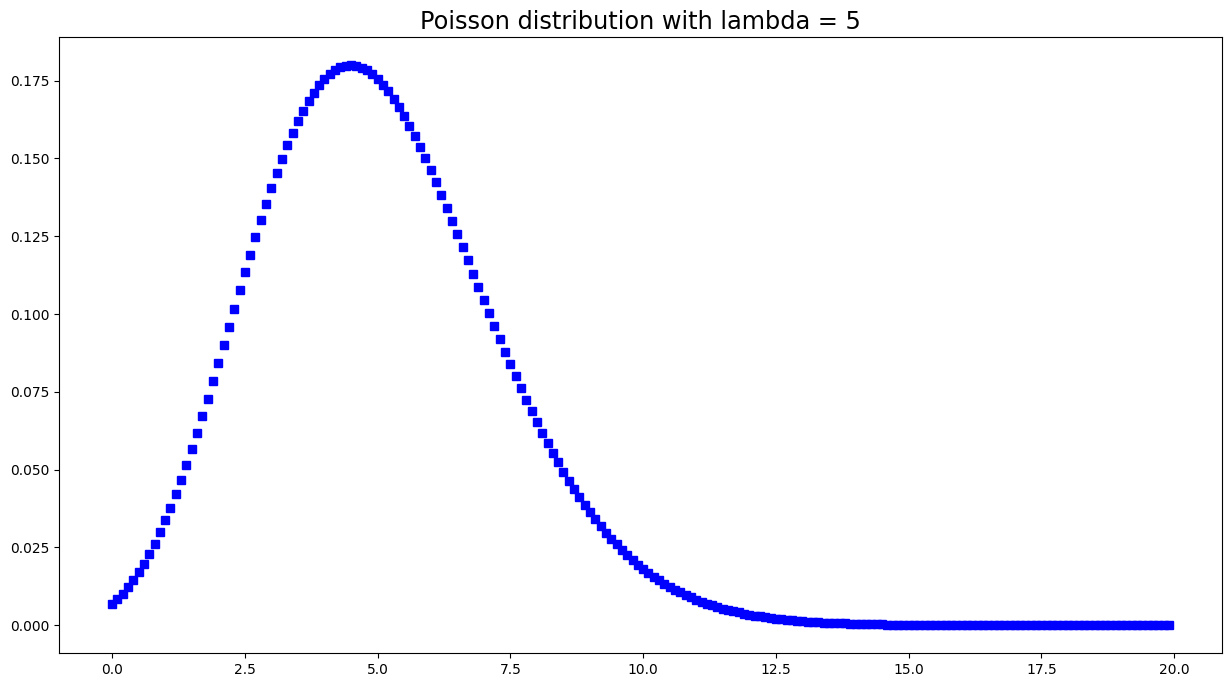

In [14]:
x = np.arange(0, 20, 0.1)
y = np.exp(-5)*np.power(5, x)/factorial(x)

plt.figure(figsize=(15,8))
plt.title('Poisson distribution with lambda = 5', fontsize='xx-large')
plt.plot(x, y, 'bs')
plt.show()

Text(0.5, 1.0, 'Visualization of log-normal PDF and CDF')

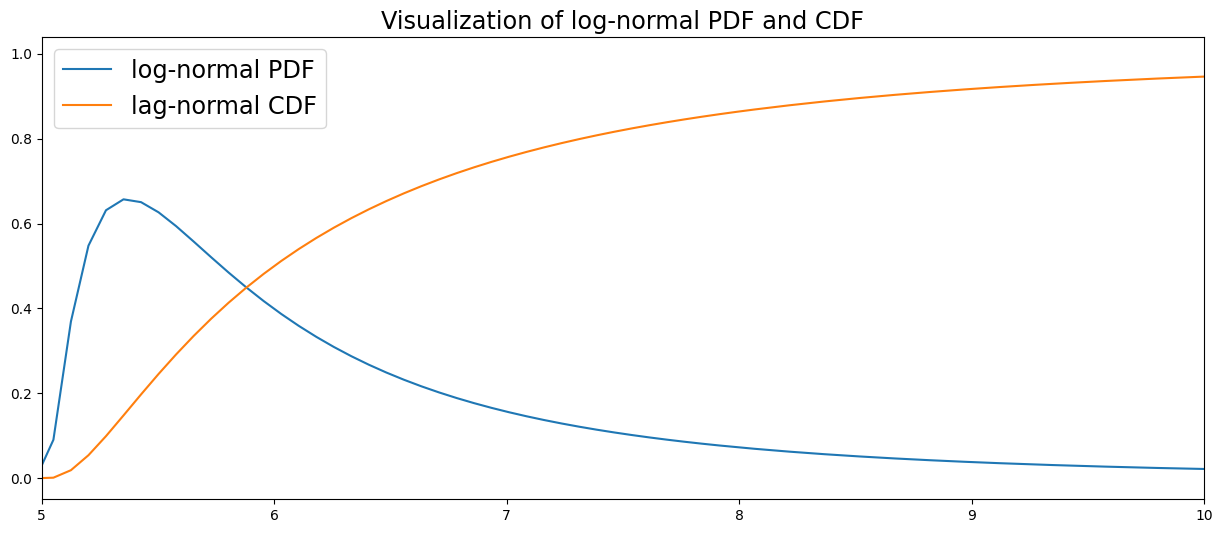

In [15]:
# Specify standard deviation and mean
std = 1
mean = 5

# Create log-normal distribution
dist=lognorm(std,loc=mean)
x= np.linspace(0,15,200)

# Visualization log-normal distribution
plt.figure(figsize=(15,6))
plt.xlim(5, 10)
plt.plot(x, dist.pdf(x), label = 'log-normal PDF')
plt.plot(x, dist.cdf(x), label = 'lag-normal CDF')
plt.legend(fontsize = 'xx-large')
plt.title('Visualization of log-normal PDF and CDF', fontsize='xx-large')

In [16]:
# Summary
print('Summary Statistics for a normal distribution: ')
#Median
medi = median(normal_dist)
print('Median: ', medi)
display(normal_df.describe())

# Standard Deviation
std = sqrt(np.var(normal_dist))

print('The first four calculated moments of a normal distribution: ')
# Mean
mean = normal_dist.mean()
print('Mean: ', mean)

# Variance
var = np.var(normal_dist)
print('Variance: ', var)

# Return unbiased skew normalized by N - 1
skew = normal_df['value'].skew()
print('Skewness: ', skew)

# Return unbiased kurtosis over requested axis using Fisher's definition of kurtosis
# (kurtosis of normal == 0.0) narmalized by N-1
kurt = normal_df['value'].kurtosis()
print('Kurtsis: ', kurt)

Summary Statistics for a normal distribution: 
Median:  -0.009719229601303074


,value
count,10000.000000
mean,-0.001870
std,0.993486
min,-3.387720
25%,-0.666088
50%,-0.009719
75%,0.677547
max,4.475463


The first four calculated moments of a normal distribution: 
Mean:  -0.0018701985520070792
Variance:  0.9869152474931443
Skewness:  0.0010162349841364468
Kurtsis:  0.0380470244564628


In [17]:
# Take sample
normal_df_sample = normal_df.sample(100)

# Calculate Expected Value (EV), population mean and bias
ev = normal_df_sample.mean()[0]
pop_mean = normal_df.mean()[0]
bias = ev - pop_mean

C:\Users\ADITYA\AppData\Local\Temp\ipykernel_15232\2703849781.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ev = normal_df_sample.mean()[0]
C:\Users\ADITYA\AppData\Local\Temp\ipykernel_15232\2703849781.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pop_mean = normal_df.mean()[0]


In [18]:
print('Sample mean (Expected Value): ', ev)
print('Population mean: ', pop_mean)
print('Bias: ', bias)

Sample mean (Expected Value):  -0.12200906484405191
Population mean:  -0.0018701985520070792
Bias:  -0.12013886629204483


In [19]:
from math import sqrt

Y = 100
YH = 94

def MSE(Y, YH):
    return np.square(YH - Y).mean()

def RMSE(Y, YH):
    return sqrt(np.square(YH - Y).mean())

print('MSE: ', MSE(Y, YH))
print('RMSE: ', RMSE(Y, YH))

MSE:  36.0
RMSE:  6.0


In [20]:
# Srandard Error (SE)
uni_sample = uniform_dist.sample(100)
norm_sample = normal_dist.sample(100)

print('Standard Error of uniform sample: ', sem(uni_sample))
print('Standard Error of normal sample: ', sem(norm_sample))


Standard Error of uniform sample:  0.029463707494034336
Standard Error of normal sample:  0.09563638383731222


In [21]:
# Note thet we take very small samples just tonillustrate the diffrent sampling method

print('---Non-Representative samples:---\n')
# Convenience Sample
con_samples = normal_dist[0:5]
print('Haphazard samples: \n\n{}\n'.format(con_samples))

# Haphazard samples (Picking out some numbers)
hap_samples = [normal_dist[12], normal_dist[55], normal_dist[582], normal_dist[821], normal_dist[999]]
print('Haphazard samples:\n\n{}\n'.format(hap_samples))

# Purposive samples(Pick samples for a specific purpose)
# In this example we pick the 5 highest values in our distribution
purp_samples = normal_dist.nlargest(n=5)
print('Purposive samples:\nn\n{}\n'.format(purp_samples))

print('---Representative samples:---\n')

# Simple (pseudo) random samples
rand_samples = normal_dist.sample(5)
print('Random samples:\n\n{}\n'.format(rand_samples))

# Systematic sample (Every 2000th value)
sys_samples = normal_dist[normal_dist.index % 2000 == 0]
print('Systematic samples:\n\n{}\n'.format(sys_samples))

# Stratified Sampling
# We Will get 01 person from every city in the dataset
# We have 8 cities so that makes a total of 8 samples
df = pd.read_csv('toy_dataset.csv')

strat_samples = []

for city in df['City'].unique():
    samp = df[df['City'] == city].sample(1)
    strat_samples.append(samp['Income'].item())
    
print('Stratified samples:\n\n{}\n'.format(strat_samples))
 
c1 = normal_dist.sample(10)
c2 = normal_dist.sample(10)
c3 = normal_dist.sample(10)
c4 = normal_dist.sample(10)
c5 = normal_dist.sample(10)

clusters = [c1, c2, c3, c4, c5]
clusters_samples = []
for c in clusters:
    clus_samp = c.sample(1)
    clusters_samples.extend(clus_samp) 
print('Cluster samples:\n\n{}\n'.format(clusters_samples))

---Non-Representative samples:---

Haphazard samples: 

0    0.104745
1    0.209456
2    0.844007
3   -0.462595
4   -0.775157
dtype: float64

Haphazard samples:

[np.float64(0.4754650203789954), np.float64(0.8950252065029604), np.float64(-1.6772758175454912), np.float64(-0.599017667779049), np.float64(-0.25905905263341183)]

Purposive samples:
n
3798    4.475463
1761    4.332372
1271    3.922695
697     3.700835
9643    3.560072
dtype: float64

---Representative samples:---

Random samples:

9589    0.018442
877     2.162519
9551   -1.247028
8195    1.187384
5630   -1.909778
dtype: float64

Systematic samples:

0       0.104745
2000    0.182870
4000   -0.272965
6000    1.829969
8000   -0.655148
dtype: float64

Stratified samples:

[38589.0, 99185.0, 97730.0, 133870.0, 78085.0, 74169.0, 100852.0, 108508.0]

Cluster samples:

[-1.656088886101919, 1.1688625814073037, -0.8582233024548965, -1.47186767158451, 1.4711840946032755]



In [22]:
print('Covariance between Age and Income: ')

df[['Age', 'Income']].cov()

Covariance between Age and Income: 


,Age,Income
Age,133.922426,-3.811863e+02
Income,-381.186341,6.244752e+08


In [23]:
print('Pearson: ')
print(df[['Age', 'Income']].corr(method='pearson'))

x1 = [1, 3, 3, 4, 6, 7, 7, 9, 10, 10]
x2 = [9.7, 9.3, 7, 6, 7, 7.2, 6, 4.2, 4.5, 4]

y1 = [0, 1, 2, 2.3, 3, 4, 4, 7, 9, 9.5]
y2 = [2.2, 4, 3, 5, 5.3, 5, 7, 9, 5, 10]

print('\nx1,x2 correlation: \n', np.corrcoef(x1, x2))
print('\ny1,y2 correlation: \n', np.corrcoef(y1, y2))

Pearson: 
             Age    Income
Age     1.000000 -0.001318
Income -0.001318  1.000000

x1,x2 correlation: 
 [[ 1.         -0.88237093]
 [-0.88237093  1.        ]]

y1,y2 correlation: 
 [[1.        0.7737071]
 [0.7737071 1.       ]]


In [24]:
print('Sperman: ')
df[['Age', 'Income']].corr(method='spearman')

Sperman: 


,Age,Income
Age,1.000000,-0.001452
Income,-0.001452,1.000000


<Axes: title={'center': 'Well fitted but not well fitting: Linear regression plot on quadratic data'}>

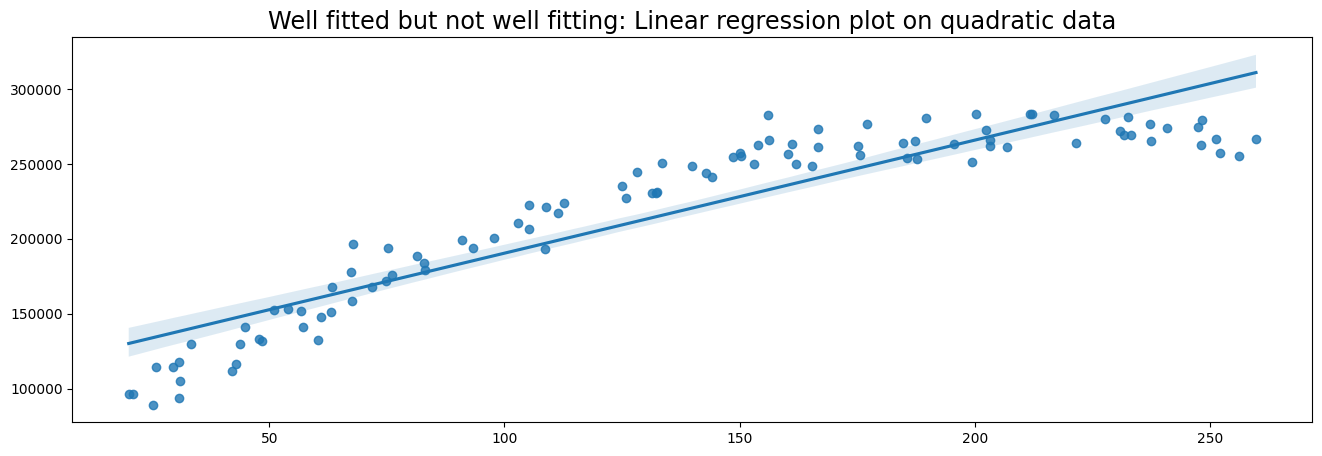

In [25]:
x = np.random.uniform(low=20, high=260, size=100)
y = 50000 + 2000*x - 4.5 * x**2 + np.random.normal(size=100, loc=0, scale=10000)

plt.figure(figsize=(16, 5))
plt.title('Well fitted but not well fitting: Linear regression plot on quadratic data', fontsize = 'xx-large')
sns.regplot(x=x, y=y)


Slope: 5.134971892986022
Intercept: -8.54787648758473


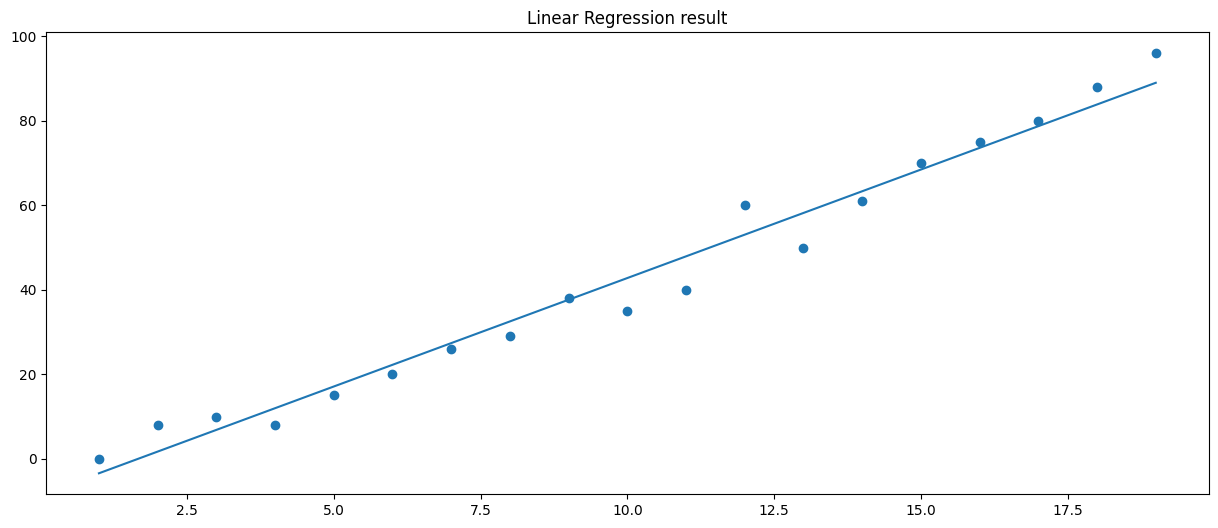

In [26]:
# linear regression from scratch
import random
# Create data from regression 
xs = np.array(range(1,20))
ys = [0,8,10,8,15,20,26,29,38,35,40,60,50,61,70,75,80,88,96]

# Put data in dictionary
data = dict()
for i in list(xs):
    data.update({xs[i-1] : ys[i-1]})
    
# Slope
m = 0
# y intercept
b = 0
# Learning rate
lr = 0.0001
# Number of epochs
epochs = 100000

# Formula for linear line
def lin(x):
    return m * x + b

# Linear regression algorithm
for i in range(epochs):
    # Pick a random point and calculate vertical distance and horizontal distance
    rand_point = random.choice(list(data.items()))
    vert_dist = abs((m * rand_point[0] + b) - rand_point[1])
    hor_dist = rand_point[0]
    
    if (m * rand_point[0] + b) - rand_point[1] < 0:
        #Adjust line upwords
        m += lr * vert_dist * hor_dist
        b += lr * vert_dist
        
    else:
        #Adjust line downwords
        m -= lr * vert_dist * hor_dist
        b -= lr * vert_dist
        
# Plot data points and regression line
plt.figure(figsize=(15, 6))
plt.scatter(data.keys(), data.values())
plt.plot(xs, lin(xs))
plt.title('Linear Regression result')
print('Slope: {}\nIntercept: {}'.format(m, b))

Means of Bootstrap Samples: 
110284    133043.0
120116     64684.0
15226      30922.0
89594     116077.0
5890       26030.0
112815    129318.0
121137     88204.0
144096    111289.0
136310     89390.0
102431    143161.0
Name: Income, dtype: float64

Mean of the population:  91384.1556
Standard Deviation of the population:  25237.382348939664


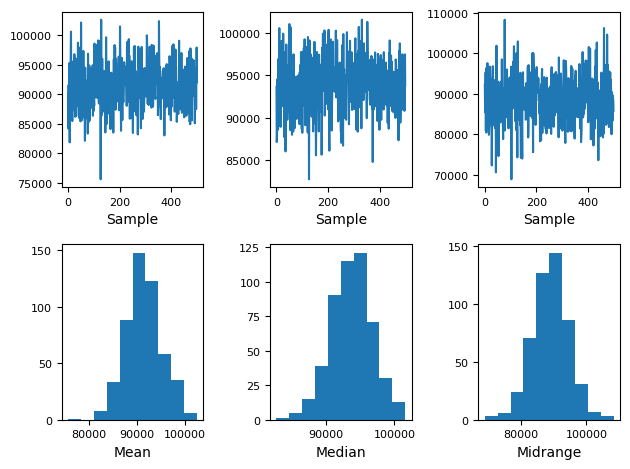

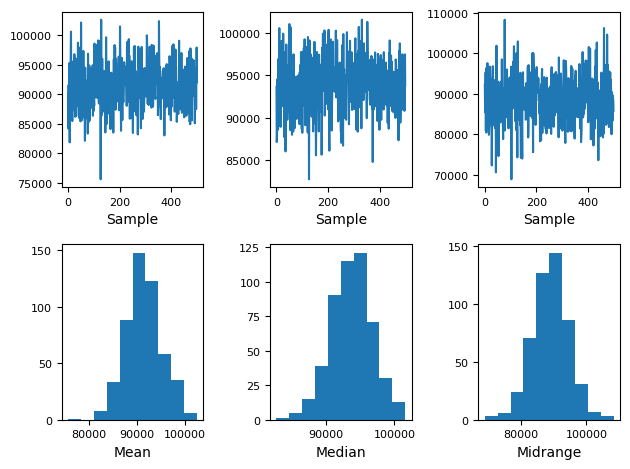

In [27]:
# Scikit-learn bootstrap package
from sklearn.utils import resample

# data sample
data = df['Income'].sample(10000)

# prepare bootstrap samples
boot = resample(data, replace=True, n_samples=10, random_state=1)
print('Means of Bootstrap Samples: \n{}\n'.format(boot))
print('Mean of the population: ', data.mean())
print('Standard Deviation of the population: ', data.std())

# Bootstrap plot
pd.plotting.bootstrap_plot(data)


In [28]:
# Perform t-test and compute p value of two random samples
print('T-statistics and p-value of two random samples.')
for _ in range(10):
    rand_sample1 = np.random.random_sample(10)
    rand_sample2 = np.random.random_sample(10)
    print(stats.ttest_ind(rand_sample1, rand_sample2))

T-statistics and p-value of two random samples.
TtestResult(statistic=np.float64(0.11426556231809354), pvalue=np.float64(0.9102922001377585), df=np.float64(18.0))
TtestResult(statistic=np.float64(0.7134922134498544), pvalue=np.float64(0.48469021433334925), df=np.float64(18.0))
TtestResult(statistic=np.float64(-0.6085632524420279), pvalue=np.float64(0.5504172974763644), df=np.float64(18.0))
TtestResult(statistic=np.float64(-0.33017924132936377), pvalue=np.float64(0.7450763783812022), df=np.float64(18.0))
TtestResult(statistic=np.float64(0.5457864201376421), pvalue=np.float64(0.5919132489442622), df=np.float64(18.0))
TtestResult(statistic=np.float64(-0.3377740384105019), pvalue=np.float64(0.7394407920007883), df=np.float64(18.0))
TtestResult(statistic=np.float64(-0.8973514061943684), pvalue=np.float64(0.3813772516295003), df=np.float64(18.0))
TtestResult(statistic=np.float64(1.7025179395151122), pvalue=np.float64(0.10586444147978805), df=np.float64(18.0))
TtestResult(statistic=np.float64

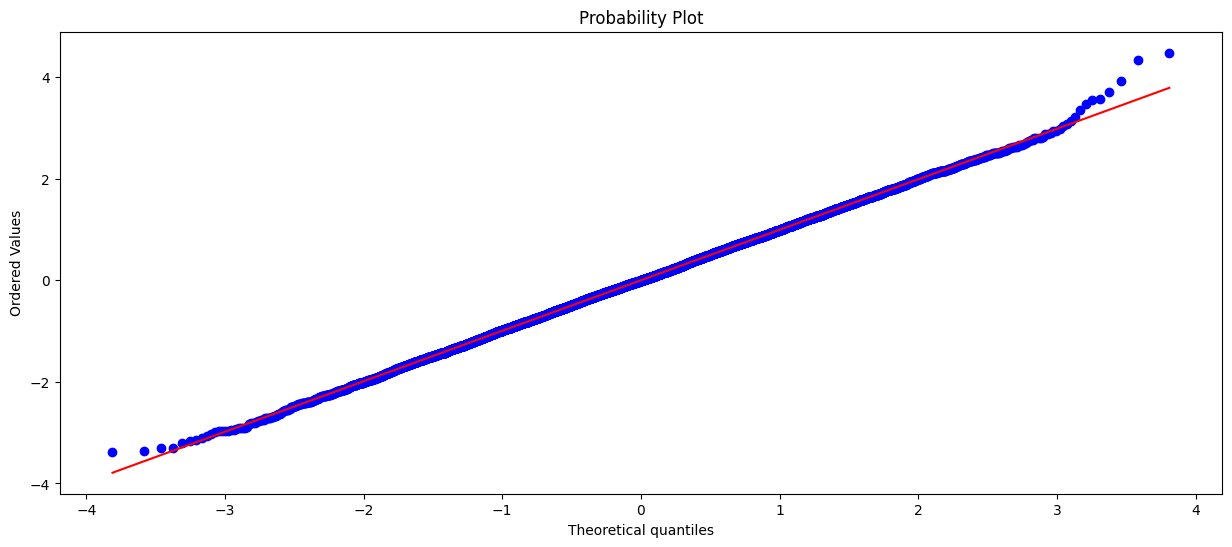

In [29]:
# q-q plot of a normal distribution
plt.figure(figsize=(15,6))
stats.probplot(normal_dist, dist="norm", plot=plt)
plt.show()

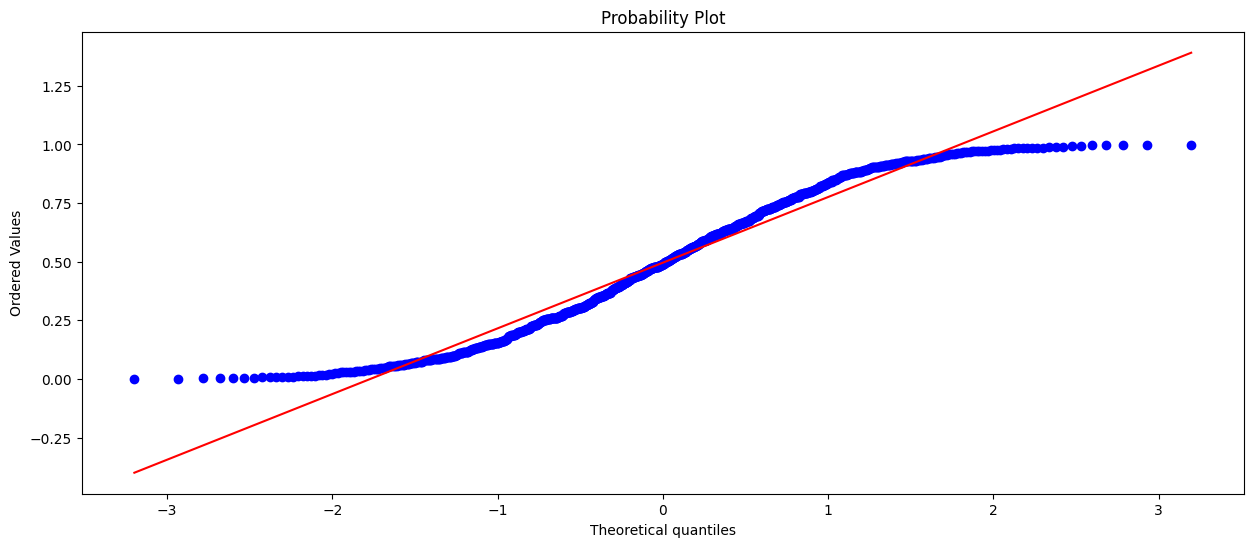

In [30]:
# q-q plot of uniform/random distribution
plt.figure(figsize=(15,6))
stats.probplot(uniform_dist, dist="norm", plot=plt)
plt.show()

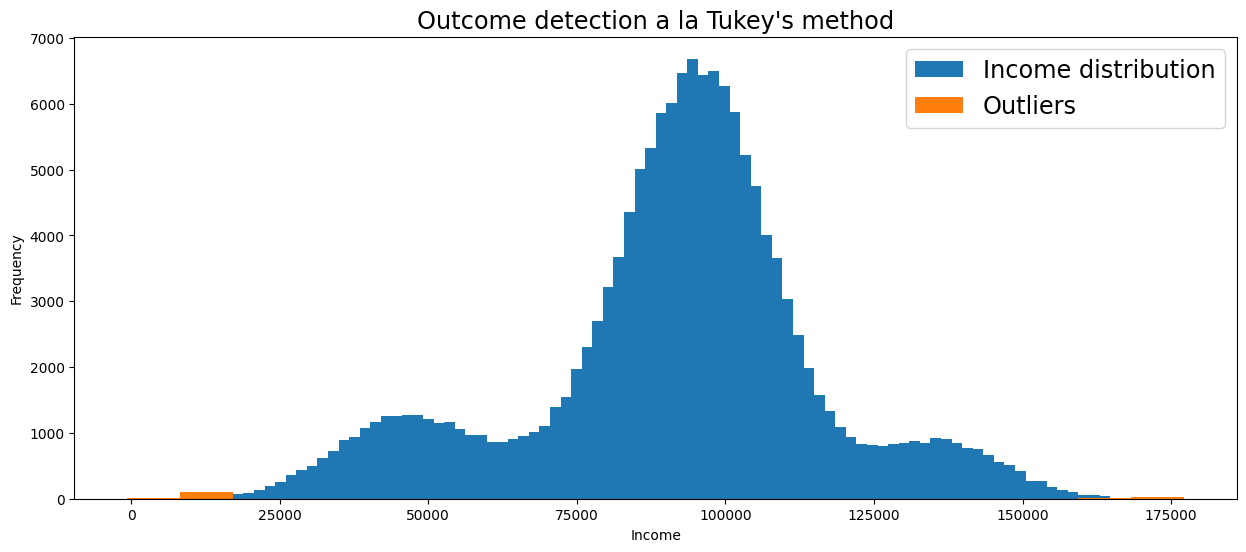

In [31]:
# Detect outliers on the 'Income' column of the Toy Dataset

# Function for detecting outliers a la Tukey's method using z-scores
def tukey_outliers(data) -> list:
    # For more information on calculating the threshold check out:
    # https://medium.com/datadriveninvestor/finding-outliers-in-dataset-using-python-efc3fce6ce32
    threshold = 3
    
    mean = np.mean(data)
    std = np.std(data)
    
    # Spot and collect outliers
    outliers = []
    for i in data:
        z_score = (i - mean) / std
        if abs(z_score) > threshold:
            outliers.append(i)
    return outliers

# Get outliers
income_outliers = tukey_outliers(df['Income'])

# Visualize distribution and outliers
plt.figure(figsize=(15,6))
df['Income'].plot(kind='hist', bins=100, label='Income distribution')
plt.hist(income_outliers, bins=20, label='Outliers')
plt.title("Outcome detection a la Tukey's method", fontsize='xx-large')
plt.xlabel('Income')
plt.legend(fontsize='xx-large')

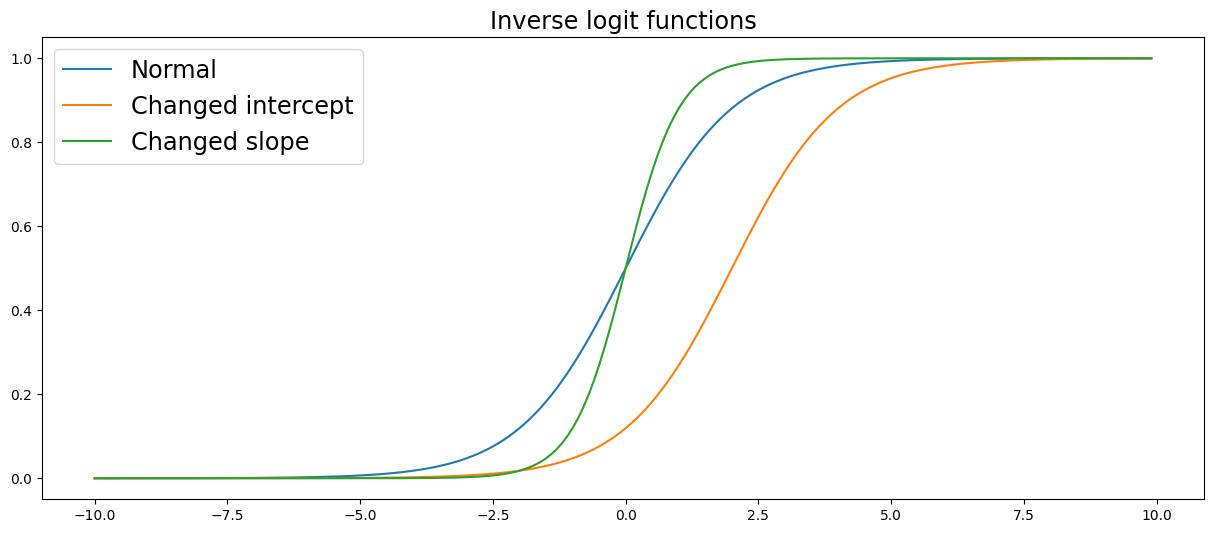

In [32]:
# Inverse logit function (link function)
def inv_logit(x):
    return 1/ (1 + np.exp(-x))

t1 = np.arange(-10, 10, 0.1)
plt.figure(figsize=(15,6))
plt.plot(t1, inv_logit(t1),
         t1, inv_logit(t1-2),
         t1, inv_logit(t1*2))
plt.title('Inverse logit functions', fontsize='xx-large')
plt.legend(('Normal', 'Changed intercept', 'Changed slope'), fontsize='xx-large')

In [37]:
# Simple example of Logistic Reggression in Python
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)

# Logistic regression classifier
clf = LogisticRegression(random_state=0,
                         solver='lbfgs',
                         multi_class='multinomial').fit(X, y)

print('Accuracy score of logistic regression model on the Iris flower dataset: {}'.format(clf.score(X, y)))

Accuracy score of logistic regression model on the Iris flower dataset: 0.9733333333333334


C:\Users\ADITYA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\ADITYA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea